In [5]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["P08_noisy", "P08_deep_tMPPCA_5D"] #, "P08_noisy",  "P08_deep_tMPPCA_5D", "P08_tMPPCA_5D", "P08_fit_LR8"
# --- Parameters ---
Subject = "P08"
Noisy_Fit = "P08_noisy"
CRLB_threshold = 50.0  # healthy; tumor ggf. 50.0


# Define masks

In [6]:
import numpy as np

# --- helper from before ---
def make_crlb_mask(crlb, thr):
    crlb = np.asarray(crlb, dtype=np.float32)
    mask_valid = np.isfinite(crlb) & (crlb < 900)  # filters 999, inf, nan
    mask_ok = mask_valid & (crlb <= thr)
    return mask_ok, mask_valid



# --- Load masks ---
mask = np.load(f"Masks/{Subject}/mask.npy")
mask = np.swapaxes(mask, 0, -1).astype(bool)

GM_mask = np.load(f"Masks/{Subject}/GM_mask_corr_60.npy")
GM_mask = np.swapaxes(GM_mask, 0, -1).astype(bool)

WM_mask = np.load(f"Masks/{Subject}/WM_mask_corr_60.npy")
WM_mask = np.swapaxes(WM_mask, 0, -1).astype(bool)

# --- Load CRLBs ---
CRLB_Glx = np.load(f"MetabMaps/{Noisy_Fit}/Glx_sd_{Noisy_Fit}_Orig.npy")
CRLB_Glc = np.load(f"MetabMaps/{Noisy_Fit}/Glc_sd_{Noisy_Fit}_Orig.npy")
CRLB_water = np.load(f"MetabMaps/{Noisy_Fit}/water_sd_{Noisy_Fit}_Orig.npy")

CRLB_mask_Glx, CRLB_valid_Glx = make_crlb_mask(CRLB_Glx, CRLB_threshold)
CRLB_mask_Glc, CRLB_valid_Glc = make_crlb_mask(CRLB_Glc, CRLB_threshold)
CRLB_mask_water, CRLB_valid_water = make_crlb_mask(CRLB_water, CRLB_threshold)

# --- ROI base masks (static) ---
roi_gm = mask & GM_mask
roi_wm = mask & WM_mask

# --- Final masks over time (4 masks: GM/WM × Glx/Glc) ---
# Shapes:
#   roi_gm:        (x,y,z)
#   CRLB_mask_*:   (x,y,z,T)
# We broadcast roi_* over time with [..., None]

final_mask_GM_Glx = roi_gm[..., None] & CRLB_mask_Glx
final_mask_WM_Glx = roi_wm[..., None] & CRLB_mask_Glx

final_mask_GM_Glc = roi_gm[..., None] & CRLB_mask_Glc
final_mask_WM_Glc = roi_wm[..., None] & CRLB_mask_Glc

final_mask_GM_water = roi_gm[..., None] & CRLB_mask_water
final_mask_WM_water = roi_wm[..., None] & CRLB_mask_water

print("final_mask_GM_Glx:", final_mask_GM_Glx.shape)
print("final_mask_WM_Glx:", final_mask_WM_Glx.shape)
print("final_mask_GM_Glc:", final_mask_GM_Glc.shape)
print("final_mask_WM_Glc:", final_mask_WM_Glc.shape)

# Optional: compute fit-rate time courses right away
# (fraction of ROI voxels that pass CRLB at each timepoint)
den_gm = roi_gm.sum()
den_wm = roi_wm.sum()

fit_rate_GM_Glx = final_mask_GM_Glx.reshape(-1, final_mask_GM_Glx.shape[-1]).sum(axis=0) / den_gm
fit_rate_WM_Glx = final_mask_WM_Glx.reshape(-1, final_mask_WM_Glx.shape[-1]).sum(axis=0) / den_wm
fit_rate_GM_Glc = final_mask_GM_Glc.reshape(-1, final_mask_GM_Glc.shape[-1]).sum(axis=0) / den_gm
fit_rate_WM_Glc = final_mask_WM_Glc.reshape(-1, final_mask_WM_Glc.shape[-1]).sum(axis=0) / den_wm
fit_rate_GM_water = final_mask_GM_water.reshape(-1, final_mask_GM_water.shape[-1]).sum(axis=0) / den_gm
fit_rate_WM_water = final_mask_WM_water.reshape(-1, final_mask_WM_water.shape[-1]).sum(axis=0) / den_wm

print("fit_rate_GM_Glx:", fit_rate_GM_Glx)
print("fit_rate_WM_Glx:", fit_rate_WM_Glx)
print("fit_rate_GM_Water:", fit_rate_GM_water)
print("fit_rate_WM_Water:", fit_rate_WM_water)

#water = np.load(f"MetabMaps/{Subject}_noisy/Glx_amp_P08_noisy_Orig.npy")

final_mask_GM_Glx: (21, 22, 22, 8)
final_mask_WM_Glx: (21, 22, 22, 8)
final_mask_GM_Glc: (21, 22, 22, 8)
final_mask_WM_Glc: (21, 22, 22, 8)
fit_rate_GM_Glx: [0.03508772 0.10776942 0.32080201 0.46616541 0.66165414 0.75438596
 0.8245614  0.89473684]
fit_rate_WM_Glx: [0.077951   0.07572383 0.18708241 0.38084633 0.51002227 0.57683742
 0.70824053 0.86191537]
fit_rate_GM_Water: [0.9924812  0.9924812  0.99749373 1.         0.99749373 1.
 1.         0.99749373]
fit_rate_WM_Water: [0.99331849 1.         0.99777283 1.         1.         1.
 1.         1.        ]


# Load data

In [7]:
import numpy as np

def _ensure_4d(arr, T=None):
    """
    Accepts (X,Y,Z) or (X,Y,Z,T).
    If (X,Y,Z) and T is given -> broadcast to (X,Y,Z,T).
    If (X,Y,Z) and T is None -> keep 3D.
    """
    arr = np.asarray(arr)
    if arr.ndim == 4:
        return arr
    if arr.ndim == 3:
        if T is None:
            return arr
        return arr[..., None] * np.ones((1,1,1,T), dtype=arr.dtype)
    raise ValueError(f"Expected 3D/4D map, got shape {arr.shape}")

def load_metab_maps_dict(
    methods,
    metab_list=("Glx", "Glc", "water"),
    map_kind="amp",
    suffix="_Orig.npy",
    base_dir="MetabMaps",
    T=None,
    dtype=np.float32,
):
    """
    methods: list of method strings, each corresponds to folder + filename stem,
             e.g. ["P08_noisy", "P08_spinSVD", "P08_ours"]
    Returns:
      maps[method][metab] = ndarray (X,Y,Z,T) if T provided or file is 4D,
                            else (X,Y,Z)
    Loads files like:
      MetabMaps/{Method}/{Metab}_{map_kind}_{Method}_Orig.npy
      e.g. MetabMaps/P08_noisy/Glx_amp_P08_noisy_Orig.npy
    """
    maps = {}
    for method in methods:
        maps[method] = {}
        for metab in metab_list:
            path = f"{base_dir}/{method}/{metab}_{map_kind}_{method}{suffix}"
            arr = np.load(path).astype(dtype, copy=False)
            arr = _ensure_4d(arr, T=T)
            maps[method][metab] = arr
    return maps

#methods = ["P08_noisy"] #, "P08_deep_tMPPCA_5D", "P08_tMPPCA_5D"
maps = load_metab_maps_dict(methods)

#print(maps["P08_noisy"]["Glx"].shape)

# Plot time course

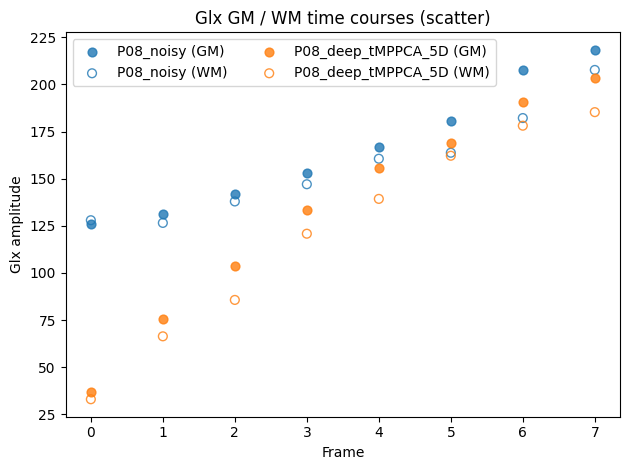

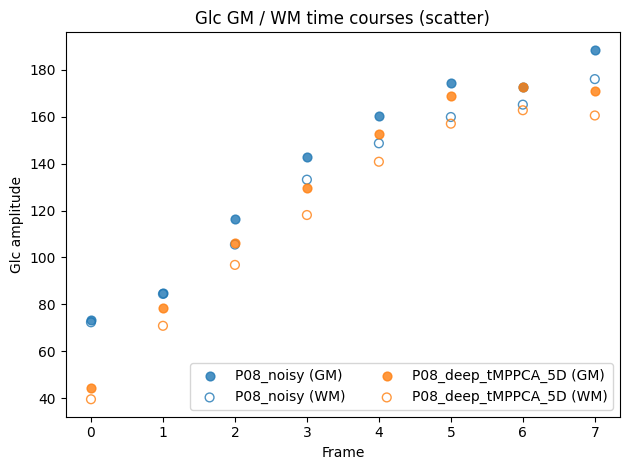

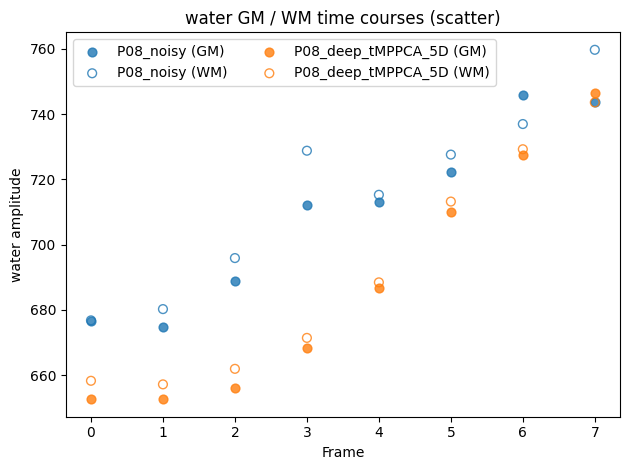

In [8]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def masked_mean_timecourse(map_4d, mask_4d):
    """
    map_4d:  (X,Y,Z,T) float
    mask_4d: (X,Y,Z,T) bool
    Returns: (T,) mean over voxels within mask at each timepoint (NaN if empty)
    """
    m = np.asarray(map_4d, dtype=np.float32).reshape(-1, map_4d.shape[-1])
    k = np.asarray(mask_4d, dtype=bool).reshape(-1, mask_4d.shape[-1])

    T = m.shape[-1]
    out = np.full((T,), np.nan, dtype=np.float32)
    for t in range(T):
        vals = m[k[:, t], t]
        if vals.size:
            out[t] = np.nanmean(vals)
    return out

def compute_gm_wm_timecourses(maps, final_masks, metab_list=("Glx", "Glc")):
    """
    maps: dict maps[method][metab] -> (X,Y,Z,T)
    final_masks: dict with keys (roi, metab) -> (X,Y,Z,T) bool, roi in {"GM","WM"}
                 e.g. final_masks[("GM","Glx")] = final_mask_GM_Glx
    Returns:
      tc[method][roi][metab] = (T,) mean timecourse
      nvox[method][roi][metab] = (T,) number of contributing voxels per timepoint
    """
    tc = {}
    nvox = {}
    for method, d in maps.items():
        tc[method] = {"GM": {}, "WM": {}}
        nvox[method] = {"GM": {}, "WM": {}}
        for metab in metab_list:
            map_4d = d[metab]
            if map_4d.ndim != 4:
                raise ValueError(f"{method}/{metab} must be 4D (X,Y,Z,T), got {map_4d.shape}")

            for roi in ("GM", "WM"):
                mask = final_masks[(roi, metab)]
                tc[method][roi][metab] = masked_mean_timecourse(map_4d, mask)
                nvox[method][roi][metab] = mask.reshape(-1, mask.shape[-1]).sum(axis=0).astype(np.int32)
    return tc, nvox

def plot_gm_wm_timecourses(tc, metab="Glx", timepoints=None, show_legend=True, lw=2.0):
    """
    One plot per metabolite.
    Same color per method:
      GM = solid
      WM = dashed
    """
    methods = list(tc.keys())
    T = len(tc[methods[0]]["GM"][metab])
    x = np.arange(T) if timepoints is None else np.asarray(timepoints)

    plt.figure()

    # get default color cycle once
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, method in enumerate(methods):
        c = colors[i % len(colors)]

        # GM – solid
        plt.plot(
            x,
            tc[method]["GM"][metab],
            color=c,
            linestyle="-",
            linewidth=lw,
            label=f"{method} (GM)",
        )

        # WM – dashed, same color
        plt.plot(
            x,
            tc[method]["WM"][metab],
            color=c,
            linestyle="--",
            linewidth=lw,
            label=f"{method} (WM)",
        )

    plt.title(f"{metab} GM / WM time courses (mean within mask)")
    plt.xlabel("Time" if timepoints is not None else "Frame")
    plt.ylabel(f"{metab} amplitude")

    if show_legend:
        plt.legend(ncol=2)

    plt.tight_layout()
    plt.show()

def plot_gm_wm_timecourses_scatter(tc, metab="Glx", timepoints=None,
                                   s=40, alpha=0.8, show_legend=True):
    """
    Scatter plot:
      - same color per method
      - GM: filled circles
      - WM: open circles
    """
    methods = list(tc.keys())
    T = len(tc[methods[0]]["GM"][metab])
    x = np.arange(T) if timepoints is None else np.asarray(timepoints)

    plt.figure()

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, method in enumerate(methods):
        c = colors[i % len(colors)]

        # GM – filled
        plt.scatter(
            x,
            tc[method]["GM"][metab],
            color=c,
            s=s,
            alpha=alpha,
            marker="o",
            label=f"{method} (GM)",
        )

        # WM – open
        plt.scatter(
            x,
            tc[method]["WM"][metab],
            facecolors="none",
            edgecolors=c,
            s=s,
            alpha=alpha,
            marker="o",
            label=f"{method} (WM)",
        )

    plt.title(f"{metab} GM / WM time courses (scatter)")
    plt.xlabel("Time" if timepoints is not None else "Frame")
    plt.ylabel(f"{metab} amplitude")

    if show_legend:
        plt.legend(ncol=2)

    plt.tight_layout()
    plt.show()



final_masks = {
    ("GM","Glx"): final_mask_GM_Glx,
    ("WM","Glx"): final_mask_WM_Glx,
    ("GM","Glc"): final_mask_GM_Glc,
    ("WM","Glc"): final_mask_WM_Glc,
    ("GM","water"): final_mask_GM_water,
    ("WM","water"): final_mask_WM_water
}

tc, nvox = compute_gm_wm_timecourses(maps, final_masks, metab_list=("Glx","Glc","water"))

plot_gm_wm_timecourses_scatter(tc, metab="Glx")
plot_gm_wm_timecourses_scatter(tc, metab="Glc")
plot_gm_wm_timecourses_scatter(tc, metab="water")
 
